 動画から音響画像（スペクトログラム）を作るコード  

In [1]:
import librosa
import numpy as np
import torch
import cv2
import os

n_seconds=4
num_frames=8
#num_frames=16

# Datasetの__init__等で
hop_length = int((n_seconds * 22050) / (num_frames * 224)) 
# 約 49 になります。これなら4秒の音が1792ピクセルにピッタリ収まります。
print('hop_length:',hop_length)  # 8frames -> 49


hop_length: 49


In [2]:
#%%writefile video_to_spectrogram_sequence.py
import numpy as np
import cv2
import librosa
#from moviepy.editor import VideoFileClip
from moviepy import VideoFileClip,AudioFileClip
import os

def video_to_spectrogram_sequence(video_path, n_seconds=4, L_frames=8, hop_length=49):
    sr = 22050
    target_len = n_seconds * sr
    # 1. 音声の読み込み (拡張子で自動切り替え)
    try:
        ext = os.path.splitext(video_path)[1].lower()
        # 拡張子が wav なら AudioFileClip、それ以外（mp4等）なら VideoFileClip
        if ext == ".wav":
            clip = AudioFileClip(video_path)
        else:
            clip = VideoFileClip(video_path)
        with clip:
            duration = min(clip.duration, n_seconds)
            # MoviePy v2.0以降の書き方
            audio_clip = clip.audio.subclipped(0, duration) if hasattr(clip, 'audio') and clip.audio else clip.subclipped(0, duration)
            # 指定サンプリングレートでNumPy配列化
            y = audio_clip.to_soundarray(fps=sr)
            # ステレオ(2ch)なら平均をとってモノラル(1ch)に
            if len(y.shape) > 1:
                y = y.mean(axis=1)
            # 長さ調整（パディングまたはカット）
            if len(y) < target_len:
                y = np.pad(y, (0, target_len - len(y)))
            else:
                y = y[:target_len]
            clip.close()
    except Exception as e:
        print(f"Audio extraction error: {e}")
        y = np.zeros(target_len)

    # add by nishi 2026.4.17
    # 音声を -1.0 〜 1.0 の範囲に正規化する
    if True:
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))
    
    # 2. メルスペクトログラムの計算
    # 黒パディングを消すために hop_length=49 を使用
    #hop_length = 49
    S = librosa.feature.melspectrogram(y=y.astype(np.float32), sr=sr, n_mels=224, hop_length=hop_length)
    
    S_dB = librosa.power_to_db(S, ref=np.max)
    # 3. データの正規化 (-80dB〜0dB を 0〜255に)
    S_norm = ((S_dB + 80) / 80 * 255).clip(0, 255).astype(np.uint8)

    # 16枚で224幅を切り出すための計算 (1792 / 16 = 112)
    #if L_frames==8:
    #    step = 224
    #if L_frames==16:
    #    step = 112
    step=int(1792/ L_frames)
        
    # 4. 時間軸方向にL_frames個の画像に分割
    # hop_length=49 なら total_width はほぼ 1792 (224*8) になります
    spectrogram_frames = []
    for i in range(L_frames):
        start = i * step
        end = start + 224
        frame = S_norm[:, start:end]
        
        # 端っこで幅が足りない場合はパディング
        if frame.shape[1] < 224:
            frame = np.pad(frame, ((0,0), (0, 224 - frame.shape[1])), mode='constant')
        
        # 1. RGB化 [H, W, C]
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
        
        # 2. 【重要】正規化 (0-255 -> 0-1 & mean/std)
        # 後の可視化でエラーが出ないよう、ここで計算を済ませるのが安全です
        frame_float = frame_rgb.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        frame_normalized = (frame_float - mean) / std
        
        # 3. 【ここを修正】[H, W, C] -> [C, H, W] に変換
        frame_final = frame_normalized.transpose(2, 0, 1)
        spectrogram_frames.append(frame_final)
        
    return np.array(spectrogram_frames,dtype=np.float32) # 戻り値は [L, 3, 224, 224]


3. モデルの変更点（AutoEncoder構成）  
「正常音を復元する」ために、VideoTransformerの最後を「元の画像に戻す構造（Decoder）」に変更します。  

In [3]:
#%%writefile VideoAutoEncoder.py

import torch
import torch.nn as nn
from torchvision import models
from torchvision import transforms
import torchvision.transforms.functional as F

class VideoAutoEncoder(nn.Module):
    def __init__(self, num_frames=8): # 16に変更
        super(VideoAutoEncoder, self).__init__()
        # エンコーダ（ResNet + Transformer）
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Transformerの定義
        #encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True),
            num_layers=3)
        
        # デコーダ（512次元のベクトルから 224x224 の画像を復元する簡易的な構成）
        self.decoder = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 224 * 224),
            nn.Sigmoid() # 0-1の範囲に出力
        )

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        features = self.backbone(x).view(b, t, -1)
        
        # Transformerで時系列の特徴を統合
        z = self.transformer(features) # [b, t, 512]
        
        # 各フレームを復元
        reconstructed = self.decoder(z) # [b, t, 224*224]
        return reconstructed.view(b, t, 1, 224, 224) # モノクロ画像として復元


4. 学習の考え方  
    正常な洗濯機の脱水動画だけを集めます。  
    Loss = nn.MSELoss()（平均二乗誤差）を使い、「入力した画像と、復元された画像がいかに同じか」を学習させます。  
    学習が終わったら、異音（ガタガタ音など）のする動画を入力します。  
    「正常な音のパターンしか知らないAI」は、異音のスペクトログラムをうまく復元できず、Loss（誤差）が跳ね上がります。  
  
この「復元誤差（Loss）がしきい値を超えたらアラートを出す」という仕組みで、未知の故障を検知します。  


音響用（スペクトログラム）の Dataset クラスを作成します。  
これまでの VideoFolderDataset と同様、指定したフォルダ（正常音の動画が入ったフォルダ）から動画を読み込み、音声をスペクトログラム画像のシーケンスに変換して返します。
実装のポイント  
  
    音声の画像化: librosa を使い、動画の音声を 224x224 の「音の画像」に変換します。  
    正常音のみの学習: AutoEncoder のため、ラベル（正解クラス）は返さず、「入力と同じ画像」を正解データとして返します（または学習ループ内で入力を使用します）。  
    キャッシュの検討: librosa の処理は重いため、可能であれば一度変換したスペクトログラムを保存（キャッシュ）しておくと学習が速くなります。  


In [4]:
#%%writefile get_spectrogram_frames_numpy.py

import librosa
import numpy as np
import cv2

# not use this function by nishi
def get_spectrogram_frames_numpy(video_path, n_seconds=4, L_frames=8, hop_length=49):
    # 1. 音声の読み込み (PyTorch不使用)
    # librosa.loadは内部でffmpegを呼び出すので、Orange Piにffmpegが入っていれば動きます
    # sr=22050, duration=n_seconds を指定
    y, sr = librosa.load(video_path, sr=22050, duration=n_seconds)

    # 2. 長さが足りない場合のパディング (4秒分に満たない場合)
    target_samples = n_seconds * sr
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)), mode='constant')
    else:
        y = y[:target_samples]

    # 3. メルスペクトログラムの計算
    # 黒塗りを消すために計算した hop_length=49 を使用
    #hop_length = 49
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=224, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # 4. 正規化 (-80dB〜0dB -> 0〜255)
    S_norm = ((S_dB + 80) / 80 * 255).clip(0, 255).astype(np.uint8)

    # 5. L_frames 枚の画像に分割
    # 224x8枚分(1792px)を順番に切り出す
    frames = []
    for i in range(L_frames):
        start = i * 224
        frame = S_norm[:, start : start + 224]
        
        # 3チャンネル化 (ResNet18用)
        # OpenCVのcv2.mergeを使うとPyTorchなしで変換可能
        frame_rgb = cv2.merge([frame, frame, frame])
        
        # 6. 学習時のNormalize(mean/std)をNumPyで適用
        # (x / 255.0 - mean) / std
        frame_float = frame_rgb.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        frame_normalized = (frame_float - mean) / std
        
        # (H, W, C) -> (C, H, W)
        frames.append(frame_normalized.transpose(2, 0, 1))

    # [L, C, H, W] のNumPy配列を返す
    return np.array(frames, dtype=np.float32)

In [5]:
import os
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchaudio

USE_TRAIN_MODE=False

class SoundSpectrogramDataset(Dataset):
    def __init__(self, video_paths, n_seconds=4, L_frames=8, transform=None):
        """
        video_paths: mp4ファイルのパスリスト
        n_seconds: 読み込む秒数
        L_frames: 画像として切り出す枚数
        transform: 画像前処理 (ToTensor, Normalizeなど)
        """
        self.video_paths = video_paths
        self.n_seconds = n_seconds
        self.L_frames = L_frames
        self.transform = transform

        # Datasetの__init__等で
        self.hop_length = int((self.n_seconds * 22050) / (self.L_frames * 224)) 
        # 約 49 になります。これなら4秒の音が1792ピクセルにピッタリ収まります。
        print('self.hop_length:',self.hop_length)
    
    def __len__(self):
        return len(self.video_paths)

    if USE_TRAIN_MODE:
        # Dataset内の読み込み部分を書き換え
        def _get_spectrogram_frames(self, video_path):
            if True:
                # 1. メタデータを取得して元のサンプリングレートを確認
                info = torchaudio.info(video_path)
                sr_original = info.sample_rate
                
                # 2. n_seconds 秒間に相当するフレーム数を計算
                # 例: 4秒 × 44100Hz = 176400フレーム
                frames_to_load = int(self.n_seconds * sr_original)
                
                # 3. 指定したフレーム数だけ読み込む (frame_offset=0 は最初から)
                waveform, sr = torchaudio.load(video_path, frame_offset=0, num_frames=frames_to_load)
                
                # --- 以下、前回の処理 ---
                # モノクロ化
                if waveform.shape[0] > 1:
                    waveform = torch.mean(waveform, dim=0, keepdim=True)
                
                # リサンプリング (22050Hzへ)
                if sr != 22050:
                    resampler = torchaudio.transforms.Resample(sr, 22050)
                    waveform = resampler(waveform)
                
                y = waveform.numpy().flatten()
                
                # 以降、librosaのメルスペクトログラム計算へ...
    
            if False:
                # 1. 音声の読み込み
                y, sr = librosa.load(video_path, duration=self.n_seconds, sr=22050)
    
            # 2. メルスペクトログラムの計算
            # n_mels=224 で縦方向の解像度を ResNet に合わせる
            # n_fft, hop_length は適宜調整（ここでは標準的な値）
            #S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=224, hop_length=512)
    
            # --- _get_spectrogram_frames 内 ---
            S = librosa.feature.melspectrogram(
                y=y, 
                sr=22050, 
                n_mels=224, 
                hop_length=self.hop_length # ここに指定
            )
            S_dB = librosa.power_to_db(S, ref=np.max)
            # 3. 正規化 (-80dB〜0dB -> 0〜255)
            S_norm = ((S_dB + 80) / 80 * 255).clip(0, 255).astype(np.uint8)
    
            # 4. L_frames 枚の画像に分割
            total_time_steps = S_norm.shape[1]
            # 1枚あたりの幅（時間軸）を 224 に設定
            frame_width = 224
            # L枚を均等にサンプリングするためのインデックス
            indices = np.linspace(0, max(0, total_time_steps - frame_width), self.L_frames).astype(int)
            frames = []
            for start in indices:
                frame = S_norm[:, start : start + frame_width]
                # 端数が出る場合は 0 でパディング
                if frame.shape[1] < frame_width:
                    frame = np.pad(frame, ((0, 0), (0, frame_width - frame.shape[1])), mode='constant')
                # ResNetに合わせて3チャンネル(RGB)にする
                frame_rgb = Image.fromarray(frame).convert("RGB")
                
                if self.transform:
                    frame_rgb = self.transform(frame_rgb)
                frames.append(frame_rgb)
            return torch.stack(frames) # [L, 3, 224, 224]

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        try:
            # 入力と「正解（ターゲット）」として同じスペクトログラムを返す
            if USE_TRAIN_MODE:
                spectrogram_sequence = self._get_spectrogram_frames(video_path)
                #print('spectrogram_sequence.shape:',spectrogram_sequence.shape)
                #print('spectrogram_sequence.dtype:',spectrogram_sequence.dtype)
            else:
                spectrogram_sequence = video_to_spectrogram_sequence(video_path, 
                                        n_seconds=self.n_seconds, 
                                        L_frames=self.L_frames, 
                                        hop_length=self.hop_length)
                
            return spectrogram_sequence, spectrogram_sequence
        except Exception as e:
            print(f"Error loading {video_path}: {e}")
            # エラー時はゼロテンソルを返す（バッチ処理を止めないため）
            dummy = torch.zeros((self.L_frames, 3, 224, 224))
            return dummy, dummy

# --- 実行例 ---
# 正常音の動画が入っているフォルダからパスを取得
#normal_video_dir = "datasets/washing_machine_normal"
normal_video_dir = "datasets/bike/normal"

video_files = [os.path.join(normal_video_dir, f) for f in os.listdir(normal_video_dir) if f.endswith('.mp4') or f.endswith('.wav')]

In [6]:
# 前処理 (ResNetのNormalizeを使用)
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = SoundSpectrogramDataset(video_files, n_seconds=n_seconds, L_frames=num_frames, transform=preprocess)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

self.hop_length: 49


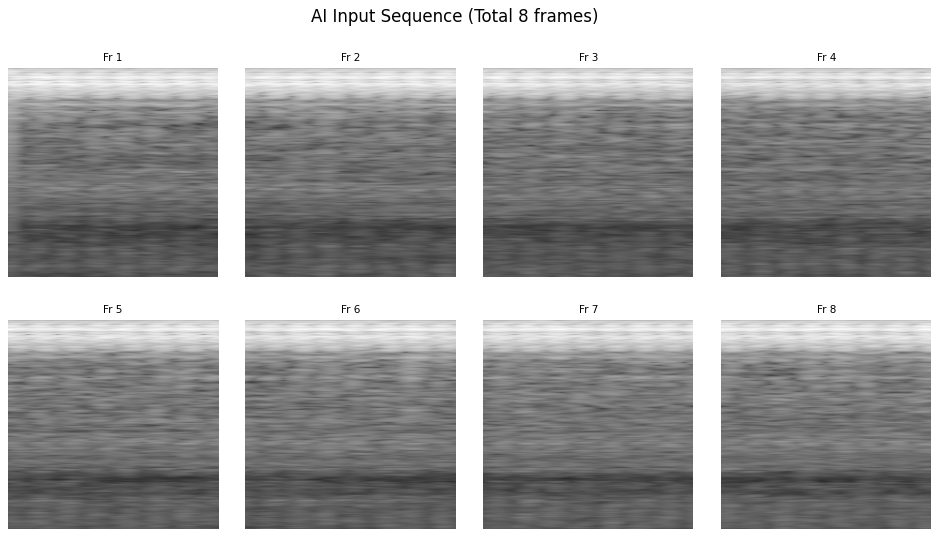

1枚あたりの入力サイズ: 224x224 px


In [7]:
#Dataloaderの中身を可視化するコード
if False:
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 1. 最初の1バッチを取得
    # inputsの形状: [Batch, Time, Channel, Height, Width]
    inputs, _ = next(iter(dataloader))
    
    print('inputs.shape:',inputs.shape)
    
    # 2. 最初のデータの、最初のフレーム（画像）を取り出す
    # [Channel, Height, Width]
    img_tensor = inputs[0, 0] 
    
    # 3. 前処理(Normalize)を逆算して表示用に変換
    # 逆算しないと色が不自然に見えるため、平均と標準偏差を戻します
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # [C, H, W] -> [H, W, C] に変換し、NumPyにする
    img_numpy = img_tensor.permute(1, 2, 0).numpy()
    img_numpy = (img_numpy * std) + mean # 正規化を戻す
    img_numpy = np.clip(img_numpy, 0, 1)  # 0-1の範囲に収める
    
    # 4. 表示
    plt.figure(figsize=(6, 6))
    plt.imshow(img_numpy)
    plt.title(f"Dataloader Output\nShape: {img_tensor.shape}")
    plt.axis('off')
    plt.show()
    
    print(f"バッチサイズ: {inputs.shape[0]}")
    print(f"時系列枚数 (L_frames): {inputs.shape[1]}")

if True:
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 1. 最初の1バッチを取得 [B, T, C, H, W]
    inputs, _ = next(iter(dataloader))
    batch_img = inputs[0] # 最初のバッチを選択 [8, 3, 224, 224]
    
    # 2. 正規化を戻すための値
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    if False:
        # 3. グラフの設定
        # 8枚並べるので、横長に設定。dpi（解像度）を指定すると実寸に近づきます。
        # figsize=(横, 縦) の単位はインチです。
        fig, axes = plt.subplots(1, 8, figsize=(16, 2), dpi=100)
        
        for i in range(8):
            # [C, H, W] -> [H, W, C]
            img = batch_img[i].permute(1, 2, 0).cpu().numpy()
            
            # 正規化を逆算
            img = (img * std) + mean
            img = np.clip(img, 0, 1)
            
            # 表示
            axes[i].imshow(img)
            axes[i].set_title(f"Fr {i+1}", fontsize=10)
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

    if False:
        # dpi=75 に設定して、224px が画面上で約3インチ（7.5cm強）程度になるようにします
        fig, axes = plt.subplots(1, 8, figsize=(24, 3), dpi=75) 
        
        for i in range(8):
            img = batch_img[i].permute(1, 2, 0).cpu().numpy()
            img = (img * std) + mean
            img = np.clip(img, 0, 1)
            
            axes[i].imshow(img)
            axes[i].set_title(f"Fr {i+1}", fontsize=10)
            axes[i].axis('off')
        plt.subplots_adjust(wspace=0.1) # フレーム間の隙間を少し詰める
        plt.show()

    if True:
        # dpi=75 に設定して、224px が画面上で約3インチ（7.5cm強）程度になるようにします
        #fig, axes = plt.subplots(1, 8, figsize=(24, 3), dpi=75) 
        # 2行4列で表示
        fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=75)
        #fig, axes = plt.subplots(2, 4, figsize=(24, 3), dpi=75) 
        total_frames=8
        fig.suptitle(f"AI Input Sequence (Total {total_frames} frames)", fontsize=16)
        for i in range(8):
            img = batch_img[i].permute(1, 2, 0).cpu().numpy()
            img = (img * std) + mean
            img = np.clip(img, 0, 1)
            ax = axes[i // 4, i % 4]
            ax.imshow(img)
            ax.set_title(f"Fr {i+1}", fontsize=10)
            ax.axis('off')
        
        plt.subplots_adjust(wspace=0.1) # フレーム間の隙間を少し詰める
        plt.show()
    
    print(f"1枚あたりの入力サイズ: {batch_img[0].shape[1]}x{batch_img[0].shape[2]} px")


AutoEncoderによる異常検知の学習・評価コードを作成します。  
この学習のゴールは、「正常な音のパターン（スペクトログラム）だけを完璧に再現できるようにする」ことです。評価時には、再現できなかった「差分（MSE）」を異常スコアとして利用します。


In [ ]:
#1. 学習ループと評価コード
import torch.nn as nn
import torch.optim as optim

# 学習データの追加学習 
# 注) train の追加学習では、ありません。 by nishi 2026.4.22
USE_ADD_TRAIN=False

# 1. モデル、損失関数、最適化手法の準備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VideoAutoEncoder(num_frames=num_frames)

base_lr=1e-4

# 学習率スケジューラの設定
num_warmup_steps = len(dataloader) * 5  # 最初の5エポックをWarmupに充てる
#num_training_steps = len(dataloader) * num_epochs
num_training_steps = len(dataloader) * 40


if USE_ADD_TRAIN:
    num_warmup_steps = 0  # 最初の5エポックをWarmupに充てる
    #base_lr=1e-5
    MODEL_PATH = "output-8frame4sec-fix/best_loss_model.pth"  # 保存したモデルのパス
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)

# 損失関数: 入力と出力の画像の「差」を計算する
criterion = nn.MSELoss() 
#optimizer = optim.AdamW(model.parameters(), lr=1e-4)

#num_epochs = 30
#num_epochs = 50
num_epochs = 100
out_dir="output"
# 出力先のクラスフォルダを作成
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

best_path = os.path.join(out_dir, "best_loss_model.pth")

# 最適化手法 (AdamWがおすすめ)
if False:
    #optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.01)
    #optimizer = optim.AdamW(model.parameters(), lr=1e-5)
else:
    optimizer = optim.AdamW([
        #{'params': model.encoder.parameters(), 'lr': base_lr * 0.1}, # 1. ResNet部分（既存知識を壊さないよう低く）
        {'params': model.backbone.parameters(), 'lr': base_lr * 0.1}, # 1. ResNet部分（既存知識を壊さないよう低く）
        {'params': model.transformer.parameters(), 'lr': base_lr},    # 2. Transformer部分（今回の肝なので標準）
        {'params': model.decoder.parameters(), 'lr': base_lr}        # 3. デコーダー部分（標準）
    ], lr=base_lr, weight_decay=0.01)

min_loss=0.15
counter=0
patience = 20  # 20エポック連続で更新されなければ終了

def lr_lambda(current_step: int):
    if current_step < num_warmup_steps:
        # 0から1まで線形に増加
        return float(current_step) / float(max(1, num_warmup_steps))
    # Warmup後は1から0まで線形に減少
    return max(0.0, float(num_training_steps - current_step) / float(max(1, num_training_steps - num_warmup_steps)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, _ in dataloader:  # AutoEncoderなのでターゲットも自分自身(inputs)
        inputs = inputs.to(device)
        optimizer.zero_grad()
        
        # 順伝播（再構成）
        # outputsの形状: [B, T, 1, 224, 224] (モノクロ復元を想定)
        outputs = model(inputs)
        
        # ターゲットをモノクロ(1ch)に変換してLoss計算（または入力に合わせて調整）
        # ここでは簡易的に入力の1チャンネル目（R）と比較
        target = inputs[:, :, 0:1, :, :] 
        
        loss = criterion(outputs, target)
        
        loss.backward()
        optimizer.step()
        # --- 学習ループ内 ---
        # optimizer.step() の直後に scheduler.step() を入れる
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        running_loss += loss.item()
    
    avg_loss = running_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Reconstruct Loss: {avg_loss:.6f} | LR: {current_lr:.6f}")
    #print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Acc: {100.*correct_train/total_train:.2f}% | Test  Loss: {test_loss/len(test_loader):.4f} | Acc: {100.*correct_test/total_test:.2f}% | LR: {current_lr:.6f}")
    
    # 最小Lossモデルの保存
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), best_path)
        print('save best_loss')
        counter=0
    else:
        counter += 1
        if counter >= patience:
            print(f"精度が向上しなくなったため {epoch+1} エポックで早期終了します。")
            break    

    if avg_loss < min_loss:
        print("★ early stop!")
        break


print("正常モデルの学習完了。")

In [ ]:
latest_path = os.path.join(out_dir, "latest_model.pth")
# --- 5. 最後にモデルを保存 (Final Model) ---
torch.save(model.state_dict(), latest_path)
print(f"最終モデルを保存しました: {latest_path}")


In [ ]:
# 再現テスト用のコード例
model.eval() # 評価モード（学習しない）
with torch.no_grad():
    # 学習に使ったのと「同じ動画」をDatasetから1つ取り出す
    inputs, _ = next(iter(dataloader)) 
    inputs = inputs.to(device)
    
    # モデルに通す
    outputs = model(inputs)
    
    # 誤差を計算
    target = inputs[:, :, 0:1, :, :]
    reproduction_loss = criterion(outputs, target).item()

print(f"再現テストのLoss: {reproduction_loss:.6f}")


In [ ]:
#anomaly_video_path = "datasets/bike/speed/iCCc6tsElTk_trim1.mp4"
#anomaly_video_path = "datasets/bike/speed/RnSyCz9ERMw.mp4_trim1.mp4"
#anomaly_video_path = "datasets/bike/speed/yL7jbivvApg_trim3.mp4"
#anomaly_video_path = "datasets/bike/speed/iCCc6tsElTk_trim2.mp4"
anomaly_video_path = "datasets/bike/normal/HGUwKAq1kxk_trim1.mp4"
hop_length=49
#hop_length=24
#hop_length=16
# 1. 学習時と同じ関数で前処理
# [L, 3, 224, 224] の numpy 配列が返る
anomaly_frames = video_to_spectrogram_sequence(anomaly_video_path, n_seconds=4, L_frames=num_frames,hop_length=hop_length)

# 2. テンソル化してモデルへ
# [1, L, 3, 224, 224] に変換
anomaly_tensor = torch.from_numpy(anomaly_frames).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    # 復元
    output_tensor = model(anomaly_tensor)
    
    # 誤差(Loss)の計算
    # 入力のRチャンネル [1, L, 1, 224, 224] と比較
    target = anomaly_tensor[:, :, 0:1, :, :]
    anomaly_loss = torch.nn.functional.mse_loss(output_tensor, target).item()

print(f"【判定テスト】")
print(f"正常（アイドリング）の基準スコア: 0.316097")
print(f"今回のスコア（加速シーン）  : {anomaly_loss:.6f}")

# 簡易判定
threshold = 0.45 # 仮のしきい値
if anomaly_loss > threshold:
    print("結果: 異常（または未学習の動作）を検知しました！")
else:
    print("結果: 正常範囲内です。")